In [1]:
import os
import sys
import copy
# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)
    
import pandas as pd
import numpy as np

In [2]:
input_file = os.path.join("D:\\", "projects", "esat", "data", "Dataset-BatonRouge-con.csv")
index_col = "Date"

In [3]:
data_df = pd.read_csv(input_file, index_col=index_col)

In [4]:
data_df

,124-Trimethylbenzene,224-Trimethylpentane,234-Trimethylpentane,23-Dimethylbutane,23-Dimethylpentane,2-Methylheptane,3-Methylhexane,3-Methylpentane,Acetylene,Benzene,...,O-Ethyltoluene,O-Xylene,Propane,Propylene,Styrene,Toluene,Trans-2-Butene,Trans-2-Pentene,Unidentified,TNMOC
Date,,,,,,,,,,,,,,,,,,,,,
6/1/2005 6:00,0.530000,1.560001,0.460000,0.580000,0.230000,0.370,0.450000,2.460002,2.060001,1.980001,...,0.005000,1.020001,17.760011,19.200012,0.390000,3.290002,0.005000,1.400001,31.732815,166.81290
6/2/2005 3:00,2.730002,4.650003,2.550002,1.440001,0.880001,0.760,1.840001,3.680002,2.620002,3.560002,...,0.730000,2.160001,14.370009,6.200004,0.750000,12.090008,2.410002,2.220001,119.645604,272.54570
6/2/2005 6:00,1.290001,4.660003,1.270001,2.070001,0.970001,0.550,1.480001,3.880002,2.490002,3.340002,...,0.410000,1.200001,19.690012,4.210003,0.430000,6.120004,0.530000,1.300001,23.178396,188.67350
6/3/2005 3:00,4.170003,6.790004,2.180001,0.800001,1.030001,0.790,2.120001,4.940003,4.490003,5.400003,...,1.330001,3.510002,15.920010,3.680002,1.910001,16.760010,0.280000,1.850001,77.234221,282.63435
6/4/2005 3:00,1.580001,2.550002,0.810001,1.000001,0.540000,0.380,1.080001,2.110001,2.080001,2.920002,...,0.610000,1.600001,14.160009,2.540002,0.590000,7.490005,0.005000,0.940001,30.553975,149.97405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9/24/2006 6:00,0.290000,2.240001,0.620000,4.610003,0.600000,0.170,0.970001,11.940007,0.410000,3.250002,...,0.090000,0.470000,39.240025,4.520003,1.040001,3.020002,0.360000,2.880002,47.594851,285.96500
9/25/2006 6:00,0.550000,1.760001,0.470000,3.120002,0.400000,0.300,1.130001,6.330004,1.360001,1.150001,...,0.005000,0.590000,8.190005,1.060001,0.550000,2.720002,0.230000,1.080001,47.734946,134.10000
9/26/2006 3:00,0.680000,1.390001,0.460000,0.410000,0.005000,0.005,1.060001,0.920001,1.360001,1.180001,...,0.005000,0.530000,4.750003,0.800001,0.400000,2.620002,0.005000,0.300000,25.639976,64.75500


In [5]:
data_df.describe()

,124-Trimethylbenzene,224-Trimethylpentane,234-Trimethylpentane,23-Dimethylbutane,23-Dimethylpentane,2-Methylheptane,3-Methylhexane,3-Methylpentane,Acetylene,Benzene,...,O-Ethyltoluene,O-Xylene,Propane,Propylene,Styrene,Toluene,Trans-2-Butene,Trans-2-Pentene,Unidentified,TNMOC
count,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,...,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000
mean,1.447004,3.072021,1.033144,1.820278,0.614610,0.394561,1.204773,4.878146,2.328829,3.356158,...,0.432850,1.378502,15.779619,4.006126,0.645961,6.972675,0.261368,1.276222,63.201858,199.900657
std,0.932473,2.188867,0.740660,1.747124,0.432080,0.298561,0.823741,4.683536,1.336828,1.874515,...,0.307049,0.839532,11.717088,4.370810,0.673456,4.290318,0.495431,1.931251,55.225483,121.491386
min,0.005000,0.410000,0.005000,0.005000,0.005000,0.005000,0.005000,0.540000,0.380000,0.590000,...,0.005000,0.220000,2.260001,0.380000,0.005000,1.310001,0.005000,0.005000,1.020135,44.420000
25%,0.820001,1.580001,0.530000,0.640000,0.340000,0.215000,0.655000,1.720001,1.410001,1.960001,...,0.240000,0.800001,8.250005,1.285001,0.270000,3.890002,0.005000,0.405000,28.923549,113.616462
50%,1.290001,2.490002,0.820001,1.110001,0.490000,0.330000,1.050001,2.990002,1.990001,2.770002,...,0.390000,1.160001,12.270008,2.450002,0.500000,5.950004,0.090000,0.700000,50.394956,158.820000
75%,1.865001,3.865002,1.300001,2.285001,0.780000,0.535000,1.510001,5.945004,2.835002,4.440003,...,0.585000,1.735001,18.440012,4.705003,0.885001,8.690005,0.300000,1.300001,76.587424,249.795150
max,5.470003,13.560008,4.410003,10.500007,3.310002,2.480002,7.780005,29.100018,8.070005,9.330006,...,1.620001,5.290003,70.960044,24.900016,7.650005,26.870017,3.210002,17.280011,385.184875,708.467700


In [6]:
import plotly.express as px

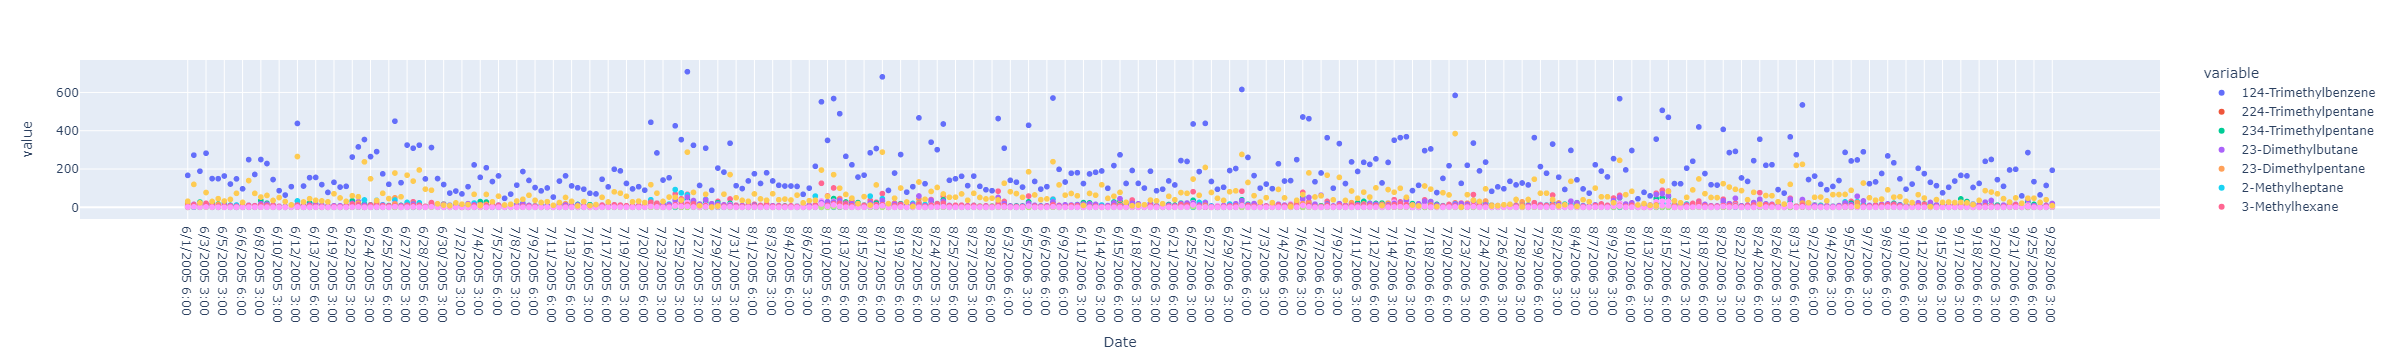

In [7]:
fig1 = px.scatter(data_df)
fig1.show()

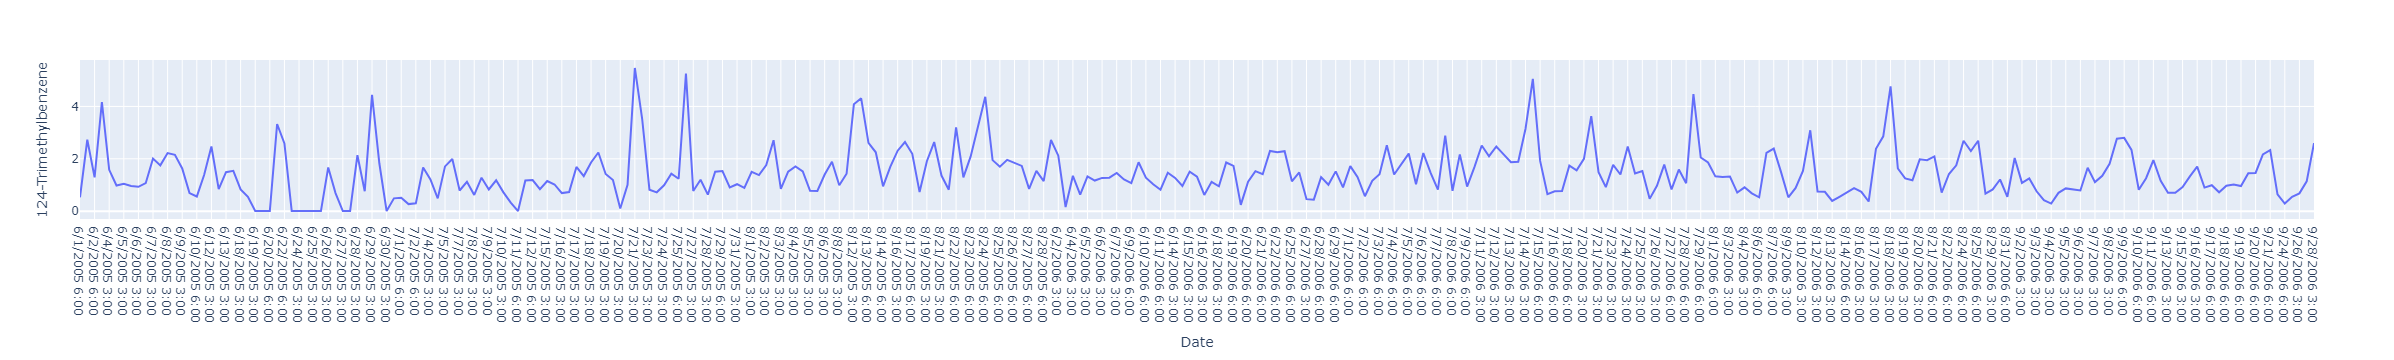

In [8]:
feature_i = '124-Trimethylbenzene'
fig2 = px.line(data_df, y=feature_i)
fig2.show()

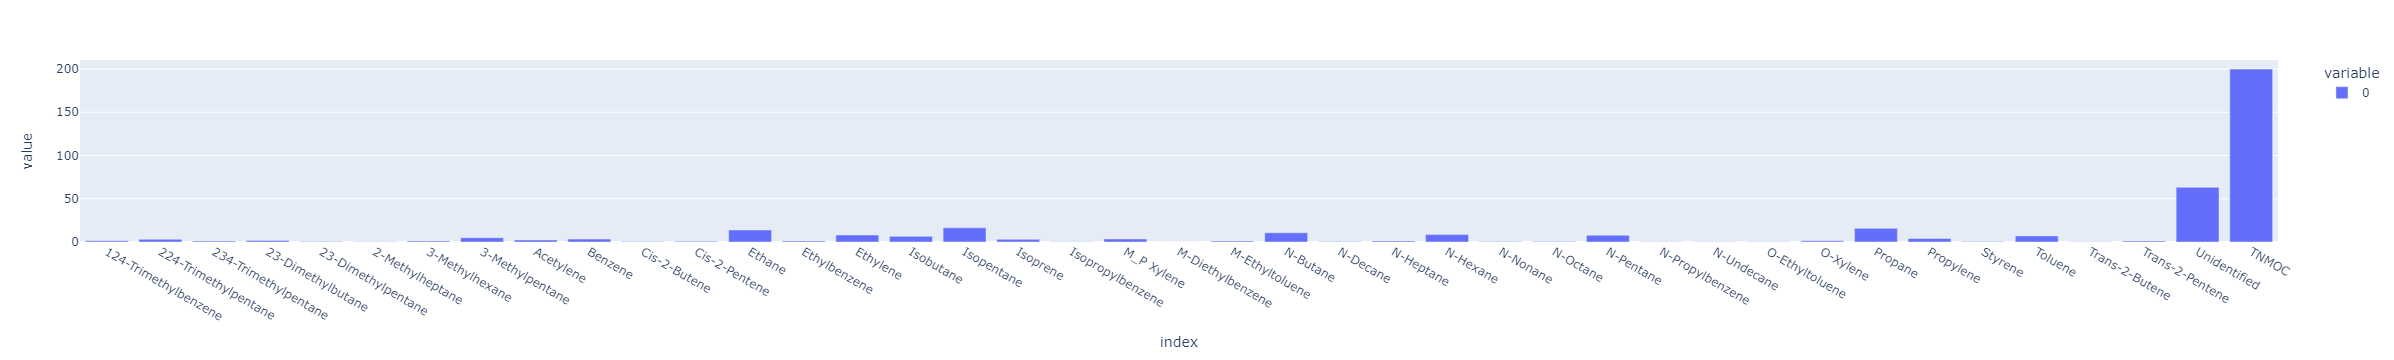

In [9]:
data_mean = data_df.mean()
fig3 = px.bar(data_mean)
fig3.show()

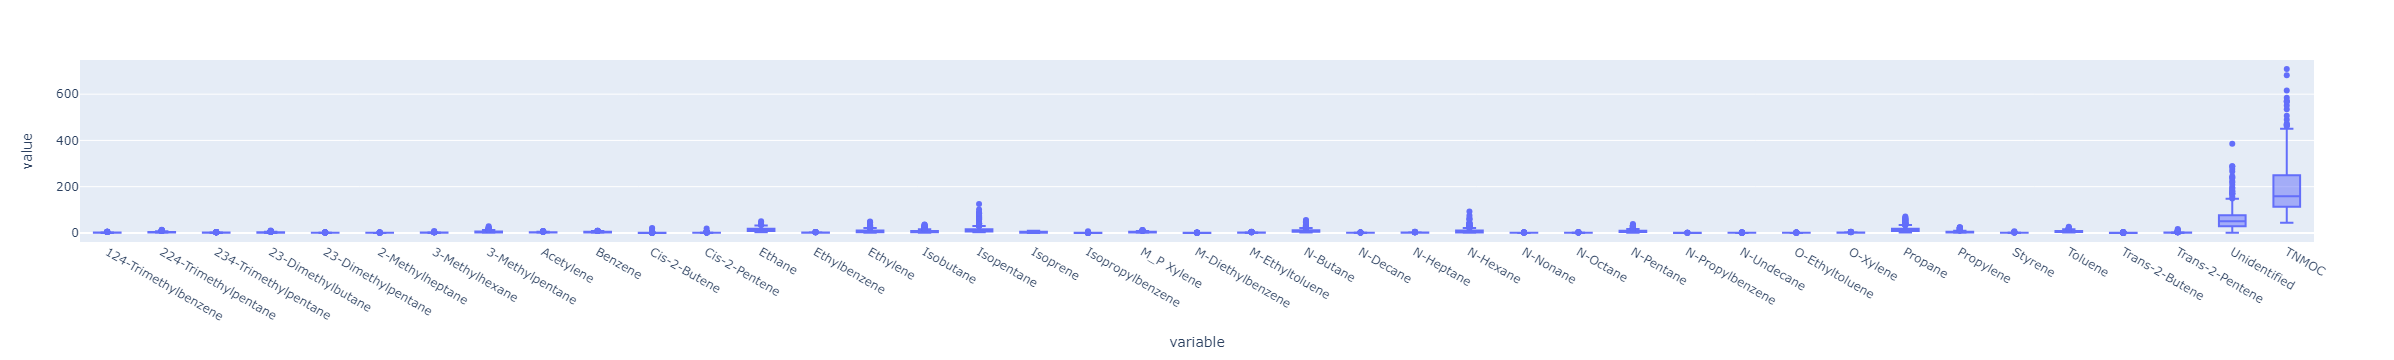

In [10]:
fig4 = px.box(data_df)
fig4.show()

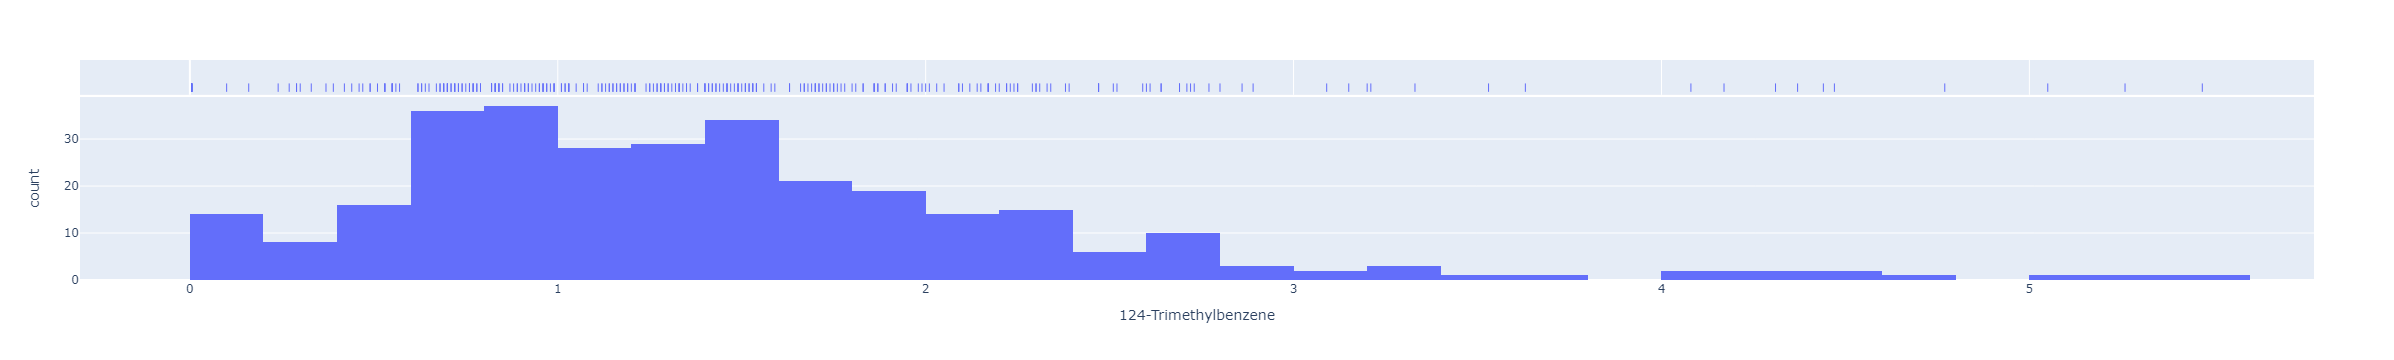

In [11]:
fig5 = px.histogram(data_df, x=feature_i, marginal='rug')
fig5.show()

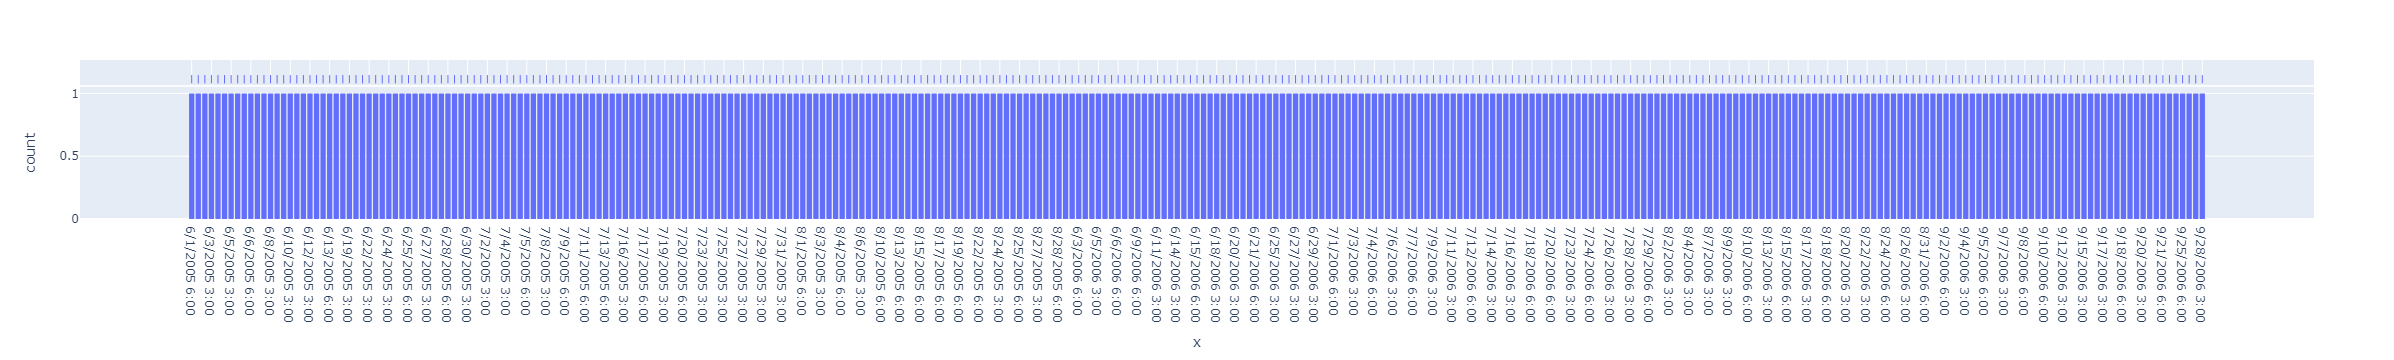

In [12]:
fig6 = px.histogram(x=data_df.index, marginal='rug')
fig6.show()

In [13]:
data_df.index = pd.to_datetime(data_df.index)
data_df = data_df.sort_index()
data_df2 = data_df.resample('D').mean()
data_df2

,124-Trimethylbenzene,224-Trimethylpentane,234-Trimethylpentane,23-Dimethylbutane,23-Dimethylpentane,2-Methylheptane,3-Methylhexane,3-Methylpentane,Acetylene,Benzene,...,O-Ethyltoluene,O-Xylene,Propane,Propylene,Styrene,Toluene,Trans-2-Butene,Trans-2-Pentene,Unidentified,TNMOC
Date,,,,,,,,,,,,,,,,,,,,,
2005-06-01,0.530000,1.560001,0.460000,0.580000,0.230000,0.3700,0.450000,2.460002,2.060001,1.980001,...,0.005000,1.020001,17.760011,19.200012,0.390000,3.290002,0.005000,1.400001,31.732815,166.81290
2005-06-02,2.010001,4.655003,1.910001,1.755001,0.925001,0.6550,1.660001,3.780002,2.555002,3.450002,...,0.570000,1.680001,17.030011,5.205003,0.590000,9.105006,1.470001,1.760001,71.412000,230.60960
2005-06-03,4.170003,6.790004,2.180001,0.800001,1.030001,0.7900,2.120001,4.940003,4.490003,5.400003,...,1.330001,3.510002,15.920010,3.680002,1.910001,16.760010,0.280000,1.850001,77.234221,282.63435
2005-06-04,1.280001,1.870001,0.600000,0.760000,0.405000,0.2800,0.860001,1.910001,2.010001,3.415002,...,0.715000,1.350001,11.280007,8.255005,0.455000,6.140004,0.077500,0.775000,37.872030,149.71210
2005-06-05,1.005001,1.685001,0.590000,0.365000,0.500000,0.2450,0.515000,3.225002,1.580001,3.215002,...,0.430000,1.105001,10.530007,3.255002,0.755000,5.340003,0.087500,0.242500,37.016034,142.51860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-09-24,0.290000,2.240001,0.620000,4.610003,0.600000,0.1700,0.970001,11.940007,0.410000,3.250002,...,0.090000,0.470000,39.240025,4.520003,1.040001,3.020002,0.360000,2.880002,47.594851,285.96500
2006-09-25,0.550000,1.760001,0.470000,3.120002,0.400000,0.3000,1.130001,6.330004,1.360001,1.150001,...,0.005000,0.590000,8.190005,1.060001,0.550000,2.720002,0.230000,1.080001,47.734946,134.10000
2006-09-26,0.910001,2.075001,0.660000,0.700000,0.237500,0.1525,1.025001,1.505001,2.420002,1.610001,...,0.207500,0.785000,7.395005,1.440001,0.370000,3.940002,0.005000,0.490000,32.652464,89.37250


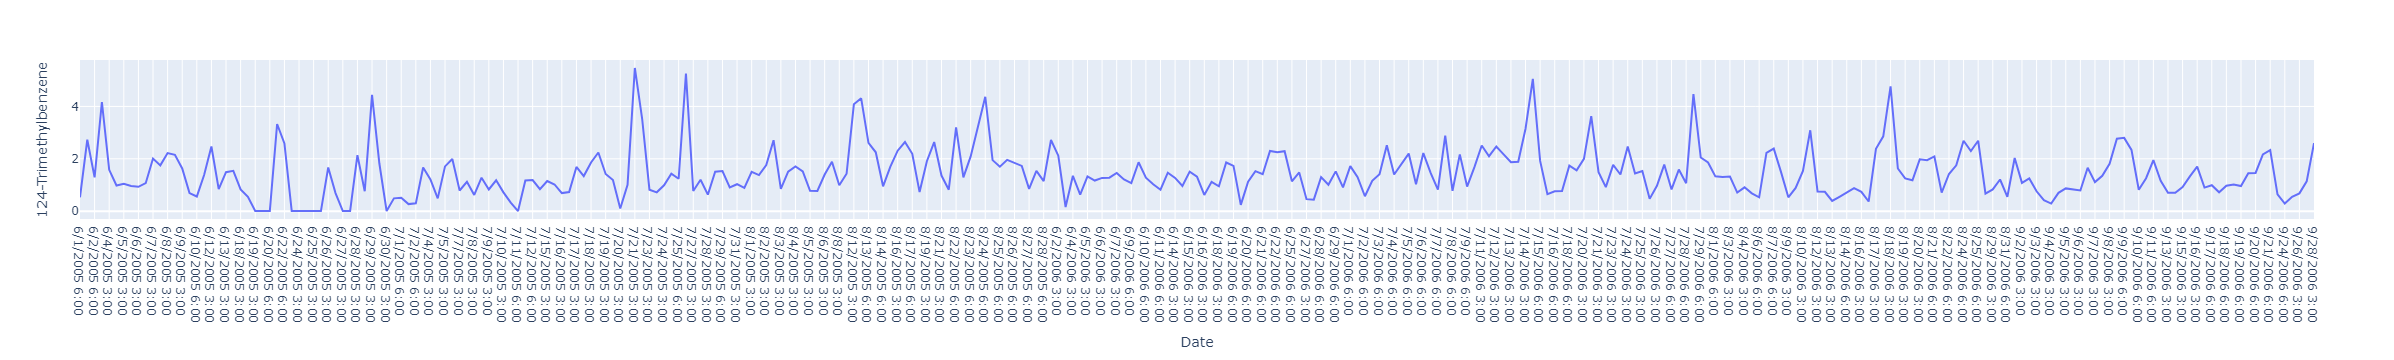

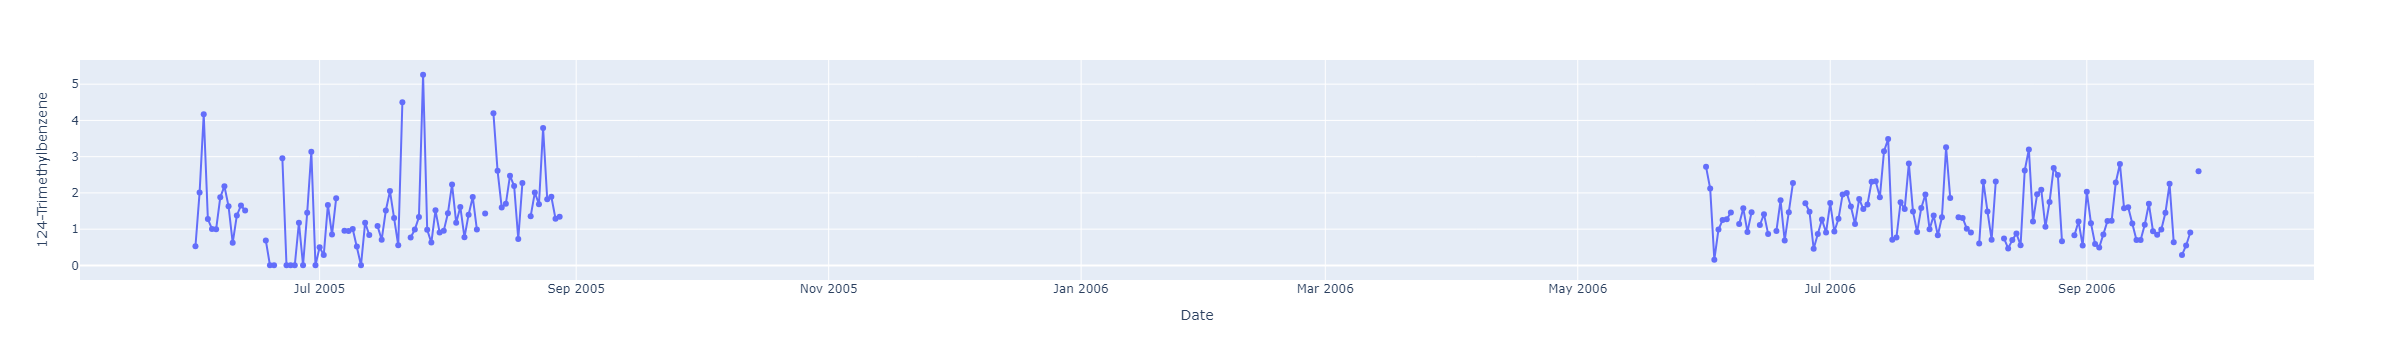

In [14]:
fig7 = px.line(data_df2, y=feature_i, markers=True)
fig2.show()
fig7.show()

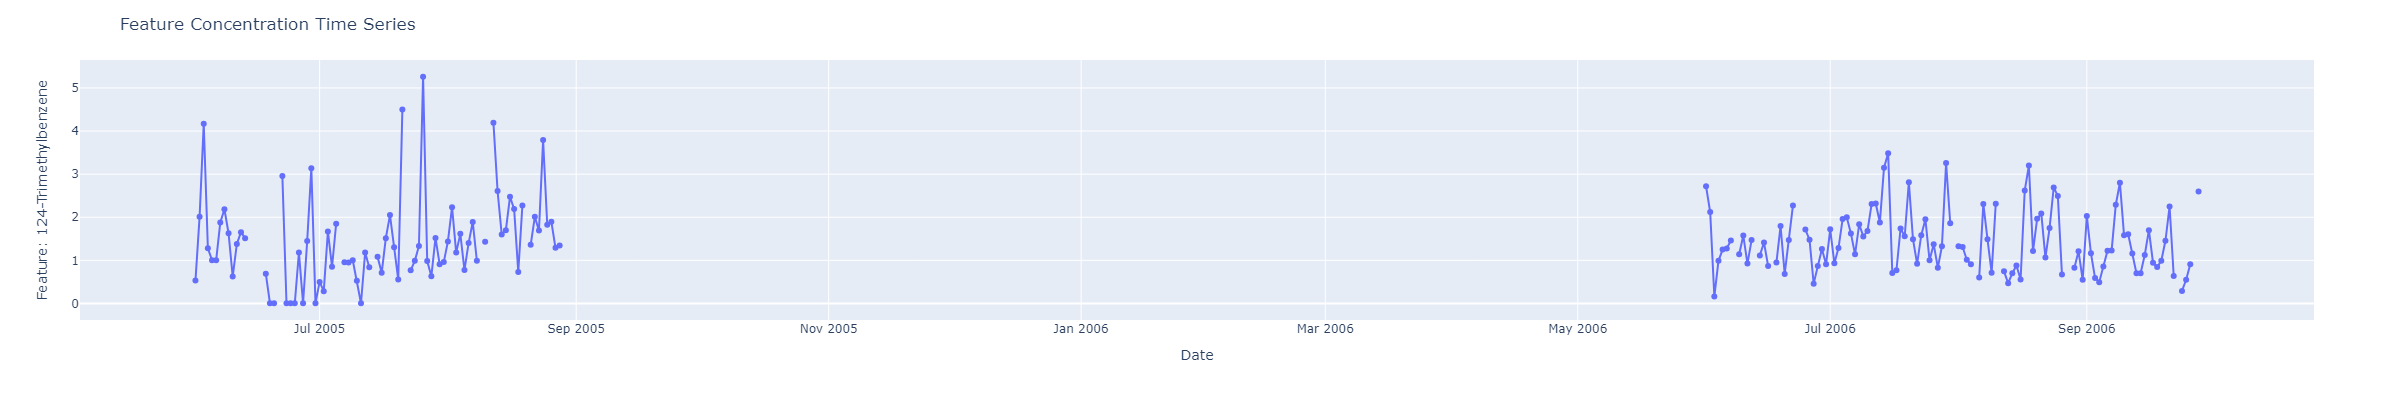

In [15]:
fig7.update_layout(width=1200, height=400, title="Feature Concentration Time Series")
fig7.update_yaxes(title=f"Feature: {feature_i}")
fig7.show()

In [16]:
import plotly.graph_objects as go

In [17]:
features = data_df2.columns
features

Index(['124-Trimethylbenzene', '224-Trimethylpentane', '234-Trimethylpentane',
       '23-Dimethylbutane', '23-Dimethylpentane', '2-Methylheptane',
       '3-Methylhexane', '3-Methylpentane', 'Acetylene', 'Benzene',
       'Cis-2-Butene', 'Cis-2-Pentene', 'Ethane', 'Ethylbenzene', 'Ethylene',
       'Isobutane', 'Isopentane', 'Isoprene', 'Isopropylbenzene', 'M_P Xylene',
       'M-Diethylbenzene', 'M-Ethyltoluene', 'N-Butane', 'N-Decane',
       'N-Heptane', 'N-Hexane', 'N-Nonane', 'N-Octane', 'N-Pentane',
       'N-Propylbenzene', 'N-Undecane', 'O-Ethyltoluene', 'O-Xylene',
       'Propane', 'Propylene', 'Styrene', 'Toluene', 'Trans-2-Butene',
       'Trans-2-Pentene', 'Unidentified', 'TNMOC'],
      dtype='object')

In [18]:
def plot_timeseries(feature_name, df):
    x = df.index
    y = df[feature_name]
    fig_ts = go.Figure()
    fig_ts.add_trace(go.Scatter(x=x, y=y, name=feature_name, mode='lines+markers'))
    fig_ts.update_layout(title=f"{feature_name} - Time Series", width=1200, height=600)
    fig_ts.update_xaxes(title="Date")
    fig_ts.update_yaxes(title="Concentration")
    fig_ts.show()


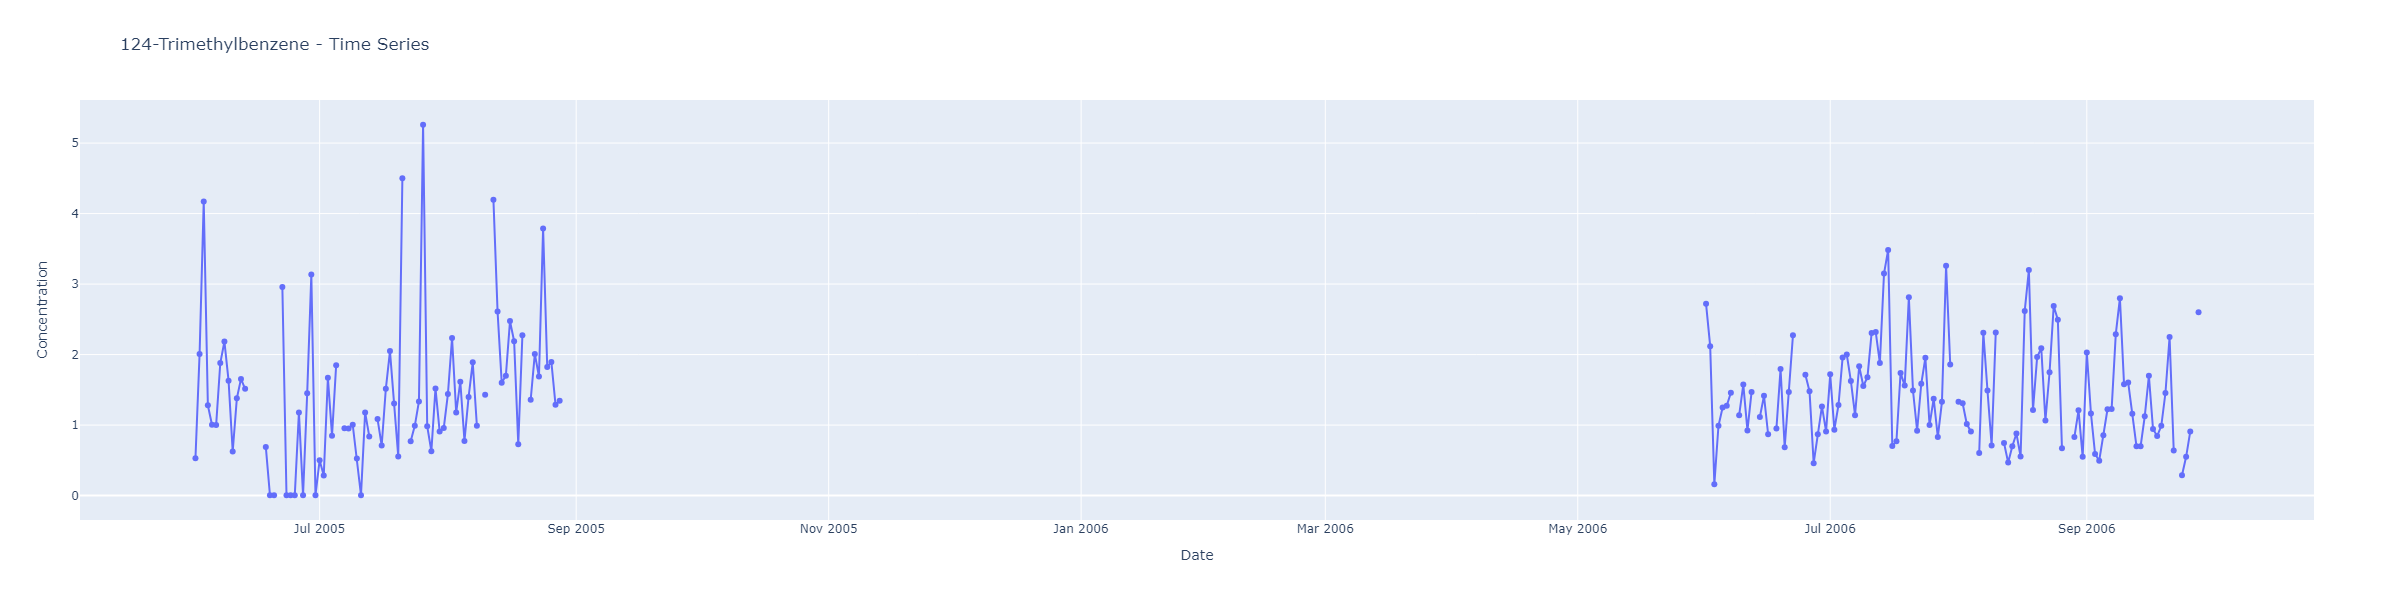

In [19]:
plot_timeseries(feature_name=features[0], df=data_df2)

In [20]:
def plot_multiple_timeseries(feature_names: list, df):
    x = df.index
    fig_ts = go.Figure()
    for feature in feature_names:
        y = df[feature]
        fig_ts.add_trace(go.Scatter(x=x, y=y, name=feature, mode='lines+markers'))
    fig_ts.update_layout(title="Feature Time Series", width=1200, height=600, hovermode='x unified')
    fig_ts.update_xaxes(title="Date")
    fig_ts.update_yaxes(title="Concentration")
    fig_ts.show()

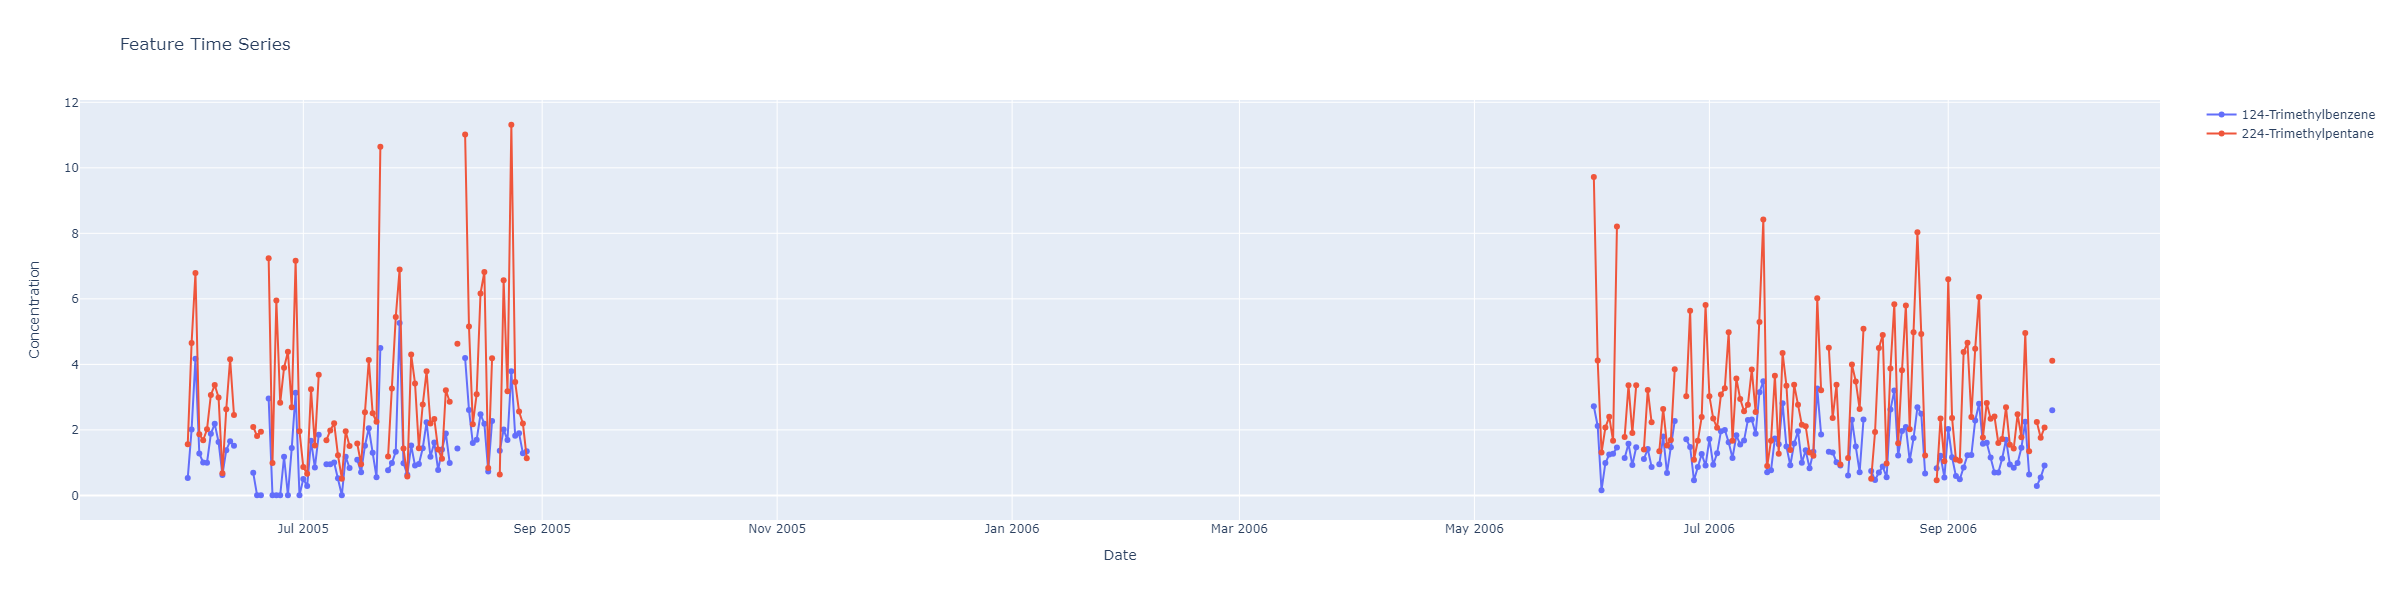

In [21]:
plot_multiple_timeseries(feature_names=features[0:2], df=data_df2)